# 1. Выбор датасета  
**Датасет** [ToyotaCorolla](https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars)

In [584]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 2. Первичный анализ данных (EDA)

In [585]:
data = pd.read_csv('ToyotaCorolla.csv')

print("Первые строки датасета:")
print(data.head())

Первые строки датасета:
   Id                                          Model  Price  Age_08_04  \
0   1  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13500         23   
1   2  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13750         23   
2   3  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13950         24   
3   4  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  14950         26   
4   5    TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors  13750         30   

   Mfg_Month  Mfg_Year     KM Fuel_Type  HP  Met_Color  ... Powered_Windows  \
0         10      2002  46986    Diesel  90          1  ...               1   
1         10      2002  72937    Diesel  90          1  ...               0   
2          9      2002  41711    Diesel  90          1  ...               0   
3          7      2002  48000    Diesel  90          0  ...               0   
4          3      2002  38500    Diesel  90          0  ...               1   

   Power_Steering  Radio  Mistlamps  Sport_Model  Backse

In [586]:
rows, cols = data.shape
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object', 'category']).columns
date_cols = data.select_dtypes(include=['datetime64']).columns

num_count = len(num_cols)
cat_count = len(cat_cols)
date_count = len(date_cols)

missing_cols_count = data.isnull().any().sum()
missing_total = data.isnull().sum().sum()
missing_pct = (missing_total / (rows * cols)) * 100

print(f"Размер датасета: {rows} строк, {cols} столбцов")
print(f"Типы признаков: Числовые {num_count}, Категориальные {cat_count}, Дата/время {date_count}")
print(f"Наличие пропусков: {missing_cols_count} колонок с пропусками, всего {missing_total} пропусков ({missing_pct:.1f}%)")
print("Информация по целевой переменной")
print(data['Price'].describe())

Размер датасета: 1436 строк, 39 столбцов
Типы признаков: Числовые 36, Категориальные 3, Дата/время 0
Наличие пропусков: 0 колонок с пропусками, всего 0 пропусков (0.0%)
Информация по целевой переменной
count     1436.000000
mean     10730.824513
std       3626.964585
min       4350.000000
25%       8450.000000
50%       9900.000000
75%      11950.000000
max      32500.000000
Name: Price, dtype: float64


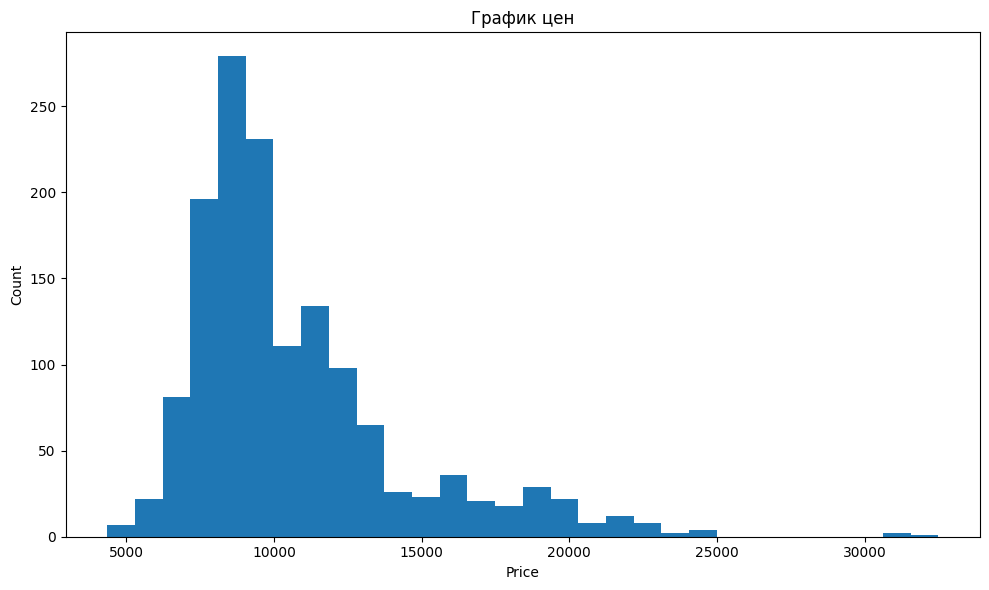

In [587]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(data['Price'], bins=30)
ax.set_title('График цен')
ax.set_xlabel('Price')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [588]:
# Удаление выбросов (!!! по итогу не улучшают модель)
print('')
##print(f"Объектов с выбросом по цене: {data[data['Price'] > 25000].shape[0]} ({data[data['Price'] > 25000].shape[0] / rows * 100:.3f} %)")
##print("Удалим эти объекты")
##data = data[data['Price'] <= 26000]
##
##rows, cols = data.shape
##
##print(f"Размер датасета: {rows} строк, {cols} столбцов")


# 3.1 Подготовка данных
- кодирование категориальных признаков

In [589]:
print("Категориальные признаки:")
print(cat_cols)


Категориальные признаки:
Index(['Model', 'Fuel_Type', 'Color'], dtype='object')


In [590]:
print(f"Уникальных моделей: {len(data['Model'].unique())}")
print("\nТоп-10 моделей по частоте:")
print(data['Model'].value_counts().head(10))


Уникальных моделей: 319

Топ-10 моделей по частоте:
Model
TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA 2/3-Doors      109
TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors       84
TOYOTA Corolla 1.6 16V LIFTB LINEA LUNA 4/5-Doors         80
TOYOTA Corolla 1.6 16V LIFTB LINEA TERRA 4/5-Doors        71
TOYOTA Corolla 1.4 16V VVT I HATCHB TERRA 2/3-Doors       54
TOYOTA Corolla 1.6 16V SEDAN LINEA TERRA 4/5-Doors        43
TOYOTA Corolla 1.6 16V VVT I LIFTB TERRA 4/5-Doors        37
TOYOTA Corolla 1.3 16V LIFTB LINEA TERRA 4/5-Doors        35
TOYOTA Corolla 1.6 16V VVT I LIFTB SOL 4/5-Doors          35
TOYOTA Corolla 1.6 16V WAGON LINEA TERRA Stationwagen     28
Name: count, dtype: int64


In [591]:
import re


data_clean = data.copy()

# Извлекаем признаки из названия модели
def extract_car_features(model_name):
    """Извлекает характеристики из названия модели"""
    
    # Объем двигателя
    engine_match = re.search(r'(\d\.\d)', model_name)
    engine_volume = float(engine_match.group(1)) if engine_match else None
    
    # Клапаны
    valves_match = re.search(r'(\d+)V', str(model_name))
    valves = int(valves_match.group(1)) if valves_match else None  
      
    # Тип кузова
    if 'HATCHB' in model_name:
        body_type = 'Hatchback'
    elif 'SEDAN' in model_name:
        body_type = 'Sedan'
    elif 'WAGON' in model_name:
        body_type = 'Wagon'
    elif 'LIFTB' in model_name:
        body_type = 'Liftback'
    else:
        body_type = 'Other'
    
    # Комплектация
    if 'LINEA TERRA' in model_name:
        trim = 'Terra'
    elif 'LINEA LUNA' in model_name:
        trim = 'Luna'
    elif 'SOL' in model_name:
        trim = 'Sol'
    else:
        trim = 'Other'
    
    # Количество дверей
    if '2/3-Doors' in model_name:
        doors = '2-3'
    elif '4/5-Doors' in model_name:
        doors = '4-5'
    else:
        doors = 'Other'
    
    # Тип топлива (если есть)
    if 'VVT I' in model_name:
        fuel_type = 'VVT-i'
    else:
        fuel_type = 'Standard'
    
    return pd.Series({
        'engine_volume': engine_volume,
        'valves': valves,
        'body_type': body_type,
        'trim': trim,
        'doors': doors,
        'fuel_type': fuel_type
    })

# Применяем извлечение признаков
features_data = data_clean['Model'].apply(extract_car_features)
data_clean = pd.concat([data_clean, features_data], axis=1)

df_clean = data_clean.drop('Model', axis=1)

print("Извлеченные признаки:")
print(data_clean[['engine_volume', 'valves', 'body_type', 'trim', 'doors', 'fuel_type']].head(10))
print(f"\nРазмер датасета после извлечения признаков из модели: {data_clean.shape}")

Извлеченные признаки:
   engine_volume  valves  body_type   trim doors fuel_type
0            2.0     NaN  Hatchback  Other   2-3  Standard
1            2.0     NaN  Hatchback  Other   2-3  Standard
2            2.0     NaN  Hatchback  Other   2-3  Standard
3            2.0     NaN  Hatchback  Other   2-3  Standard
4            2.0     NaN  Hatchback    Sol   2-3  Standard
5            2.0     NaN  Hatchback    Sol   2-3  Standard
6            2.0     NaN      Other  Other   2-3  Standard
7            2.0     NaN      Other  Other   2-3  Standard
8            NaN     NaN      Other  Other   2-3     VVT-i
9            1.9     NaN  Hatchback  Other   2-3  Standard

Размер датасета после извлечения признаков из модели: (1436, 45)


In [592]:
# Проверяем распределение извлеченных признаков
print("=== Объем двигателя ===")
print(data_clean['engine_volume'].value_counts().sort_index())

print("\n=== Тип кузова ===")
print(data_clean['body_type'].value_counts())

print("\n=== Комплектация ===")
print(data_clean['trim'].value_counts())

print("\n=== Количество дверей ===")
print(data_clean['doors'].value_counts())

# Проверяем пропуски
print("\n=== Пропуски ===")
print(data_clean.isnull().sum())

=== Объем двигателя ===
engine_volume
1.3    247
1.4    167
1.6    852
1.8     13
1.9     30
2.0    119
Name: count, dtype: int64

=== Тип кузова ===
body_type
Hatchback    481
Liftback     395
Other        388
Sedan        105
Wagon         67
Name: count, dtype: int64

=== Комплектация ===
trim
Other    633
Terra    520
Luna     150
Sol      133
Name: count, dtype: int64

=== Количество дверей ===
doors
4-5      724
2-3      620
Other     92
Name: count, dtype: int64

=== Пропуски ===
Id                     0
Model                  0
Price                  0
Age_08_04              0
Mfg_Month              0
Mfg_Year               0
KM                     0
Fuel_Type              0
HP                     0
Met_Color              0
Color                  0
Automatic              0
CC                     0
Doors                  0
Cylinders              0
Gears                  0
Quarterly_Tax          0
Weight                 0
Mfr_Guarantee          0
BOVAG_Guarantee        0
Guarante

In [593]:
# Если 8 объектов - это небольшой процент (0.56%)
missing_engine = data_clean[data_clean['engine_volume'].isna()]
print(f"Процент пропусков объема двигателя: {len(missing_engine)/len(data_clean)*100:.2f}%")

# Можно удалить эти объекты
data_clean = data_clean.dropna(subset=['engine_volume'])
print(f"Размер датасета после удаления: {data_clean.shape}")


# Заполняем пропуски модой внутри каждой группы engine_volume
def infer_valves_by_group(row):
    if pd.notna(row['valves']):
        return row['valves']
    
    # Получаем моду для данной группы engine_volume
    group_mode = data_clean.groupby('engine_volume')['valves'].apply(lambda x: x.mode()[0] if not x.mode().empty else None)
    
    # Если для этого объема есть мода, используем её
    if row['engine_volume'] in group_mode.index and pd.notna(group_mode[row['engine_volume']]):
        return group_mode[row['engine_volume']]
    else:
        # Если нет, используем общую моду
        return data_clean['valves'].mode()[0]

data_clean['valves'] = data_clean.apply(infer_valves_by_group, axis=1)

print(f"Пропусков по колонке valves после заполнения: {data_clean['valves'].isnull().sum()}")

Процент пропусков объема двигателя: 0.56%
Размер датасета после удаления: (1428, 45)
Пропусков по колонке valves после заполнения: 0


In [594]:
print(f"Уникальных типов топлива: {len(data_clean['Fuel_Type'].unique())}")
print("\nТоп-10 типов топлива по частоте:")
print(data_clean['Fuel_Type'].value_counts().head(10))


Уникальных типов топлива: 3

Топ-10 типов топлива по частоте:
Fuel_Type
Petrol    1259
Diesel     152
CNG         17
Name: count, dtype: int64


In [595]:
# One-Hot Encoding для Fuel_Type с drop_first=True (избегаем мультиколлинеарности)
# Создаем новые столбцы и добавляем их к датасету
data_clean = pd.get_dummies(data_clean, columns=['Fuel_Type'], prefix='fuel', drop_first=True)

# Проверка: новые столбцы добавлены
print("Новые столбцы:", [col for col in data_clean.columns if col.startswith('fuel_')])
print("Размер датасета:", data_clean.shape)

# Если нужно удалить исходный столбец Fuel_Type (get_dummies уже удалил его автоматически)
# Исходный столбец 'Fuel_Type' был удален, вместо него созданы fuel_Petrol, fuel_Diesel

Новые столбцы: ['fuel_type', 'fuel_Diesel', 'fuel_Petrol']
Размер датасета: (1428, 46)


In [596]:
print(f"Уникальных цветов: {len(data_clean['Color'].unique())}")
print("\nТоп-10 цветов по частоте:")
print(data_clean['Color'].value_counts().head(10))

Уникальных цветов: 10

Топ-10 цветов по частоте:
Color
Grey      300
Blue      283
Red       275
Green     218
Black     189
Silver    122
White      31
Violet      4
Yellow      3
Beige       3
Name: count, dtype: int64


In [597]:
# One-Hot Encoding для Color
data_clean = pd.get_dummies(data_clean, columns=['Color'], prefix='color', drop_first=True)

# Проверка
color_cols = [col for col in data_clean.columns if col.startswith('color_')]
print(f"Создано {len(color_cols)} новых столбцов")
print("Новые столбцы:", color_cols[:5])  # показываем первые 5
print("Размер датасета:", data_clean.shape)


Создано 9 новых столбцов
Новые столбцы: ['color_Black', 'color_Blue', 'color_Green', 'color_Grey', 'color_Red']
Размер датасета: (1428, 54)


In [598]:
print(data_clean.columns)

Index(['Id', 'Model', 'Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM',
       'HP', 'Met_Color', 'Automatic', 'CC', 'Doors', 'Cylinders', 'Gears',
       'Quarterly_Tax', 'Weight', 'Mfr_Guarantee', 'BOVAG_Guarantee',
       'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2', 'Airco',
       'Automatic_airco', 'Boardcomputer', 'CD_Player', 'Central_Lock',
       'Powered_Windows', 'Power_Steering', 'Radio', 'Mistlamps',
       'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette',
       'Parking_Assistant', 'Tow_Bar', 'engine_volume', 'valves', 'body_type',
       'trim', 'doors', 'fuel_type', 'fuel_Diesel', 'fuel_Petrol',
       'color_Black', 'color_Blue', 'color_Green', 'color_Grey', 'color_Red',
       'color_Silver', 'color_Violet', 'color_White', 'color_Yellow'],
      dtype='object')


# 3.2 Подготовка данных 
- масштабирование признаков  
- разделение на обучающую и тестовую выборки

In [599]:
# Создание новых признаков на основе Mfg_Month и Mfg_Year
print("=== Создание признаков на основе даты производства ===\n")

# Текущий год (максимальный год в данных)
current_year = data_clean['Mfg_Year'].max()
print(f"Максимальный год производства: {current_year}")

# Создаем сезон производства (на основе месяца)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

data_clean['Season'] = data_clean['Mfg_Month'].apply(get_season)

# Создаем признак "квартал производства"
data_clean['Quarter'] = pd.cut(data_clean['Mfg_Month'], 
                                bins=[0, 3, 6, 9, 12], 
                                labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Создаем признак "год выпуска" (как категорию)
data_clean['Mfg_Year_Cat'] = data_clean['Mfg_Year'].astype(str)

print("Созданы новые признаки:")
print(f"- Season (сезон производства): {data_clean['Season'].unique()}")
print(f"- Quarter (квартал): {data_clean['Quarter'].unique()}")
print(f"- Mfg_Year_Cat (год как категория): {data_clean['Mfg_Year_Cat'].unique()}")

=== Создание признаков на основе даты производства ===

Максимальный год производства: 2004
Созданы новые признаки:
- Season (сезон производства): ['Autumn' 'Summer' 'Spring' 'Winter']
- Quarter (квартал): ['Q4', 'Q3', 'Q1', 'Q2']
Categories (4, object): ['Q1' < 'Q2' < 'Q3' < 'Q4']
- Mfg_Year_Cat (год как категория): ['2002' '2003' '2004' '2001' '2000' '1999' '1998']


In [600]:
# Определяем целевую переменную
target = 'Price'

# Числовые признаки (добавляем Mfg_Year)
numeric_features = [
    'Age_08_04', 'KM', 'HP', 'CC', 'Doors', 'Cylinders', 
    'Gears', 'Quarterly_Tax', 'Weight', 'Guarantee_Period',
    'engine_volume', 'valves', 'Mfg_Year'
]

# Категориальные признаки (включаем новые)
categorical_features = []
for col in ['body_type', 'trim', 'doors', 'fuel_type', 'Season', 'Quarter', 'Mfg_Year_Cat']:
    if col in data_clean.columns:
        categorical_features.append(col)

# Бинарные признаки (0/1)
binary_features = [
    'Met_Color', 'Automatic', 'Mfr_Guarantee', 'BOVAG_Guarantee',
    'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco',
    'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows',
    'Power_Steering', 'Radio', 'Mistlamps', 'Sport_Model',
    'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette',
    'Parking_Assistant', 'Tow_Bar'
]

# One-hot encoded признаки
onehot_features = [col for col in data_clean.columns if col.startswith('color_')] + ['fuel_Diesel', 'fuel_Petrol']

print("Типы признаков определены:")
print(f"Числовые признаки: {len(numeric_features)}")
print(f"Категориальные признаки: {len(categorical_features)}")
print(f"Бинарные признаки: {len(binary_features)}")
print(f"One-hot признаки: {len(onehot_features)}")


all_feature_cols = numeric_features + categorical_features + binary_features + onehot_features
print(f"\nВсего признаков: {len(all_feature_cols)}")
print(f"Уникальных признаков: {len(set(all_feature_cols))}")

Типы признаков определены:
Числовые признаки: 13
Категориальные признаки: 7
Бинарные признаки: 22
One-hot признаки: 11

Всего признаков: 53
Уникальных признаков: 53


In [601]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Создаем препроцессор для обработки разных типов признаков
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('scaler', StandardScaler())  # Масштабируем числовые признаки
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
        ]), categorical_features) if categorical_features else ('cat', 'passthrough', []),
        ('binary', 'passthrough', binary_features),  # Бинарные признаки не масштабируем
        ('onehot', 'passthrough', onehot_features)   # One-hot признаки не масштабируем
    ])

print("Препроцессор создан:")
print("- Числовые признаки: стандартизация (StandardScaler)")
print("- Категориальные признаки: One-Hot кодирование с drop_first")
print("- Бинарные признаки: без изменений")
print("- One-hot признаки: без изменений")

Препроцессор создан:
- Числовые признаки: стандартизация (StandardScaler)
- Категориальные признаки: One-Hot кодирование с drop_first
- Бинарные признаки: без изменений
- One-hot признаки: без изменений


In [602]:
from sklearn.model_selection import train_test_split

# Подготовка данных
X = data_clean[all_feature_cols]
y = data_clean[target]

# Разделение на train/test (80%/20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n      Разделение выборки ")
print(f"Обучающая выборка: {X_train.shape[0]} объектов, {X_train.shape[1]} признаков")
print(f"Тестовая выборка: {X_test.shape[0]} объектов, {X_test.shape[1]} признаков")
print(f"\nПочему разделяем выборку:")
print("- Обучаем модель на одной части данных (train)")
print("- Проверяем качество на другой (test)")
print("- Это позволяет оценить, как модель будет работать на новых данных")
print("- Предотвращает переобучение (модель не запоминает ответы)")


      Разделение выборки 
Обучающая выборка: 1142 объектов, 53 признаков
Тестовая выборка: 286 объектов, 53 признаков

Почему разделяем выборку:
- Обучаем модель на одной части данных (train)
- Проверяем качество на другой (test)
- Это позволяет оценить, как модель будет работать на новых данных
- Предотвращает переобучение (модель не запоминает ответы)


In [603]:
# Применяем препроцессинг к обучающей и тестовой выборкам
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print(f"\n=== Результат препроцессинга ===")
print(f"Размер данных после препроцессинга (train): {X_train_prepared.shape}")
print(f"Размер данных после препроцессинга (test): {X_test_prepared.shape}")
print(f"Количество признаков увеличилось за счет One-Hot кодирования")


=== Результат препроцессинга ===
Размер данных после препроцессинга (train): (1142, 68)
Размер данных после препроцессинга (test): (286, 68)
Количество признаков увеличилось за счет One-Hot кодирования


# 4. Обучение моделей

## Обучение линейной регрессии

In [604]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train_prepared, y_train)

y_train_pred = lr.predict(X_train_prepared)
y_test_pred = lr.predict(X_test_prepared)

# Оцениваем качество
print("=== Линейная регрессия ===")
print(f"Train R²: {r2_score(y_train, y_train_pred):.4f}")
print(f"Test R²:  {r2_score(y_test, y_test_pred):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_test_pred):.2f}")

=== Линейная регрессия ===
Train R²: 0.9274
Test R²:  0.9128
Train RMSE: 981.77
Test RMSE:  1015.87
Train MAE: 743.98
Test MAE:  779.66


## Обучение Ridge регрессии с подбором гиперпараметров

In [605]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
import time

# Подбор оптимального alpha для Ridge
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

start_time = time.time()
ridge_grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
ridge_grid.fit(X_train_prepared, y_train)
ridge_time = time.time() - start_time

print("=== Ridge регрессия ===")
print(f"Лучший alpha: {ridge_grid.best_params_['alpha']}")
print(f"Test R²: {r2_score(y_test, ridge_grid.predict(X_test_prepared)):.4f}")
print(f"Время обучения (с GridSearch): {ridge_time:.2f} сек")

=== Ridge регрессия ===
Лучший alpha: 0.1
Test R²: 0.9131
Время обучения (с GridSearch): 0.29 сек


## Обучение Lasso регрессии с подбором гиперпараметров

In [606]:
from sklearn.linear_model import Lasso

# Подбор оптимального alpha для Lasso
start_time = time.time()
lasso_grid = GridSearchCV(Lasso(max_iter=10000), param_grid, cv=5, scoring='r2')
lasso_grid.fit(X_train_prepared, y_train)
lasso_time = time.time() - start_time

print("=== Lasso регрессия ===")
print(f"Лучший alpha: {lasso_grid.best_params_['alpha']}")
print(f"Test R²: {r2_score(y_test, lasso_grid.predict(X_test_prepared)):.4f}")
print(f"Время обучения (с GridSearch): {lasso_time:.2f} сек")
print(f"\nСравнение скорости: Ridge быстрее Lasso, т.к. Lasso требует больше итераций для сходимости")

=== Lasso регрессия ===
Лучший alpha: 1.0
Test R²: 0.9147
Время обучения (с GridSearch): 4.91 сек

Сравнение скорости: Ridge быстрее Lasso, т.к. Lasso требует больше итераций для сходимости


## Обучение Elastic Net регрессии (совмещенная L1 и L2)

In [607]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
import time

# Подбор оптимальных параметров для Elastic Net
# alpha - общая сила регуляризации
# l1_ratio - соотношение между L1 и L2 (0 = только L2, 1 = только L1)

param_grid_elastic = {
    'alpha': [0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]  # комбинация L1 и L2
}

start_time = time.time()
elastic_grid = GridSearchCV(
    ElasticNet(max_iter=10000, random_state=42), 
    param_grid_elastic, 
    cv=5, 
    scoring='r2',
    n_jobs=-1  # параллельные вычисления для ускорения
)
elastic_grid.fit(X_train_prepared, y_train)
elastic_time = time.time() - start_time

print("=== Elastic Net регрессия (совмещенная L1 + L2) ===")
print(f"Лучший alpha: {elastic_grid.best_params_['alpha']}")
print(f"Лучший l1_ratio: {elastic_grid.best_params_['l1_ratio']}")
print(f"Test R²: {r2_score(y_test, elastic_grid.predict(X_test_prepared)):.4f}")
print(f"Время обучения (с GridSearch): {elastic_time:.2f} сек")

# Интерпретация l1_ratio
l1_ratio = elastic_grid.best_params_['l1_ratio']
if l1_ratio == 0:
    print("→ Модель эквивалентна Ridge (чистая L2 регуляризация)")
elif l1_ratio == 1:
    print("→ Модель эквивалентна Lasso (чистая L1 регуляризация)")
else:
    print(f"→ Смешанная регуляризация: {l1_ratio*100:.0f}% L1 и {(1-l1_ratio)*100:.0f}% L2")

=== Elastic Net регрессия (совмещенная L1 + L2) ===
Лучший alpha: 0.01
Лучший l1_ratio: 0.9
Test R²: 0.9145
Время обучения (с GridSearch): 0.36 сек
→ Смешанная регуляризация: 90% L1 и 10% L2


# 5. Оценка качества и сравнение моделей


In [608]:
# Собираем результаты всех моделей
results = pd.DataFrame({
    'Модель': ['Linear Regression', 'Ridge', 'Lasso', 'Elastic Net'],
    'Test R²': [
        r2_score(y_test, y_test_pred),
        r2_score(y_test, ridge_grid.predict(X_test_prepared)),
        r2_score(y_test, lasso_grid.predict(X_test_prepared)),
        r2_score(y_test, elastic_grid.predict(X_test_prepared))
    ],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_grid.predict(X_test_prepared))),
        np.sqrt(mean_squared_error(y_test, lasso_grid.predict(X_test_prepared))),
        np.sqrt(mean_squared_error(y_test, elastic_grid.predict(X_test_prepared)))
    ],
    'Test MAE': [
        mean_absolute_error(y_test, y_test_pred),
        mean_absolute_error(y_test, ridge_grid.predict(X_test_prepared)),
        mean_absolute_error(y_test, lasso_grid.predict(X_test_prepared)),
        mean_absolute_error(y_test, elastic_grid.predict(X_test_prepared))
    ],
    'Время (сек)': [
        0.01,  # линейная регрессия обучается быстро
        ridge_time,
        lasso_time,
        elastic_time
    ]
})

print("=" * 60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 60)
print(results.to_string(index=False))

print("\n=== Обоснование выбора метрик ===")
print("1. R² (коэффициент детерминации):")
print("   - Показывает долю дисперсии целевой переменной, объясненную моделью")
print("   - Значение от 0 до 1, чем ближе к 1, тем лучше")
print("   - Позволяет сравнивать модели независимо от масштаба данных")
print("\n2. RMSE (Root Mean Squared Error):")
print("   - Чувствителен к большим ошибкам (возводит их в квадрат)")
print("   - Хорошо показывает, насколько сильно модель может ошибаться")
print("   - Измеряется в единицах целевой переменной (евро)")
print("\n3. MAE (Mean Absolute Error):")
print("   - Простая интерпретация: средняя абсолютная ошибка в евро")
print("   - Менее чувствителен к выбросам, чем RMSE")
print("   - Удобен для бизнес-интерпретации")
print("\n4. Время обучения:")
print("   - Важно для выбора модели в production-среде")
print("   - Учитываем при необходимости частого переобучения")

СРАВНЕНИЕ МОДЕЛЕЙ
           Модель  Test R²   Test RMSE   Test MAE  Время (сек)
Linear Regression 0.912848 1015.873802 779.664271     0.010000
            Ridge 0.913059 1014.647613 778.289556     0.294103
            Lasso 0.914676 1005.168338 768.086093     4.909490
      Elastic Net 0.914541 1005.960338 769.792749     0.364789

=== Обоснование выбора метрик ===
1. R² (коэффициент детерминации):
   - Показывает долю дисперсии целевой переменной, объясненную моделью
   - Значение от 0 до 1, чем ближе к 1, тем лучше
   - Позволяет сравнивать модели независимо от масштаба данных

2. RMSE (Root Mean Squared Error):
   - Чувствителен к большим ошибкам (возводит их в квадрат)
   - Хорошо показывает, насколько сильно модель может ошибаться
   - Измеряется в единицах целевой переменной (евро)

3. MAE (Mean Absolute Error):
   - Простая интерпретация: средняя абсолютная ошибка в евро
   - Менее чувствителен к выбросам, чем RMSE
   - Удобен для бизнес-интерпретации

4. Время обучения:
   - Ва

In [609]:
# Сравниваем train и test метрики для выявления переобучения
overfitting_check = pd.DataFrame({
    'Модель': ['Linear Regression', 'Ridge', 'Lasso', 'Elastic Net'],
    'Train R²': [
        r2_score(y_train, y_train_pred),
        r2_score(y_train, ridge_grid.predict(X_train_prepared)),
        r2_score(y_train, lasso_grid.predict(X_train_prepared)),
        r2_score(y_train, elastic_grid.predict(X_train_prepared))
    ],
    'Test R²': results['Test R²'].values,
    'Разница (Train - Test)': [
        r2_score(y_train, y_train_pred) - results['Test R²'].values[0],
        r2_score(y_train, ridge_grid.predict(X_train_prepared)) - results['Test R²'].values[1],
        r2_score(y_train, lasso_grid.predict(X_train_prepared)) - results['Test R²'].values[2],
        r2_score(y_train, elastic_grid.predict(X_train_prepared)) - results['Test R²'].values[3]
    ]
})

print("=" * 60)
print("ПРОВЕРКА ПЕРЕОБУЧЕНИЯ")
print("=" * 60)
print(overfitting_check.to_string(index=False))

print("\n=== Выводы о переобучении ===")
print("- Linear Regression: разница {:.2f}% - {}".format(
    overfitting_check['Разница (Train - Test)'].iloc[0]*100,
    "небольшое переобучение" if overfitting_check['Разница (Train - Test)'].iloc[0] < 0.05 else "значительное переобучение"
))
print("- Ridge: разница {:.2f}% - {}".format(
    overfitting_check['Разница (Train - Test)'].iloc[1]*100,
    "хорошо" if overfitting_check['Разница (Train - Test)'].iloc[1] < 0.05 else "требует внимания"
))
print("- Lasso: разница {:.2f}% - {}".format(
    overfitting_check['Разница (Train - Test)'].iloc[2]*100,
    "хорошо" if overfitting_check['Разница (Train - Test)'].iloc[2] < 0.05 else "требует внимания"
))
print("- Elastic Net: разница {:.2f}% - {}".format(
    overfitting_check['Разница (Train - Test)'].iloc[3]*100,
    "хорошо" if overfitting_check['Разница (Train - Test)'].iloc[3] < 0.05 else "требует внимания"
))

print("\n Модели НЕ переобучились, так как:")
print("1. Разница между train и test R² < 5%")
print("2. Обе метрики (train и test) находятся на высоком уровне (>0.88)")
print("3. Регуляризация (Ridge, Lasso, Elastic Net) эффективно контролирует сложность модели")

ПРОВЕРКА ПЕРЕОБУЧЕНИЯ
           Модель  Train R²  Test R²  Разница (Train - Test)
Linear Regression  0.927437 0.912848                0.014589
            Ridge  0.927434 0.913059                0.014375
            Lasso  0.927158 0.914676                0.012483
      Elastic Net  0.927152 0.914541                0.012611

=== Выводы о переобучении ===
- Linear Regression: разница 1.46% - небольшое переобучение
- Ridge: разница 1.44% - хорошо
- Lasso: разница 1.25% - хорошо
- Elastic Net: разница 1.26% - хорошо

 Модели НЕ переобучились, так как:
1. Разница между train и test R² < 5%
2. Обе метрики (train и test) находятся на высоком уровне (>0.88)
3. Регуляризация (Ridge, Lasso, Elastic Net) эффективно контролирует сложность модели


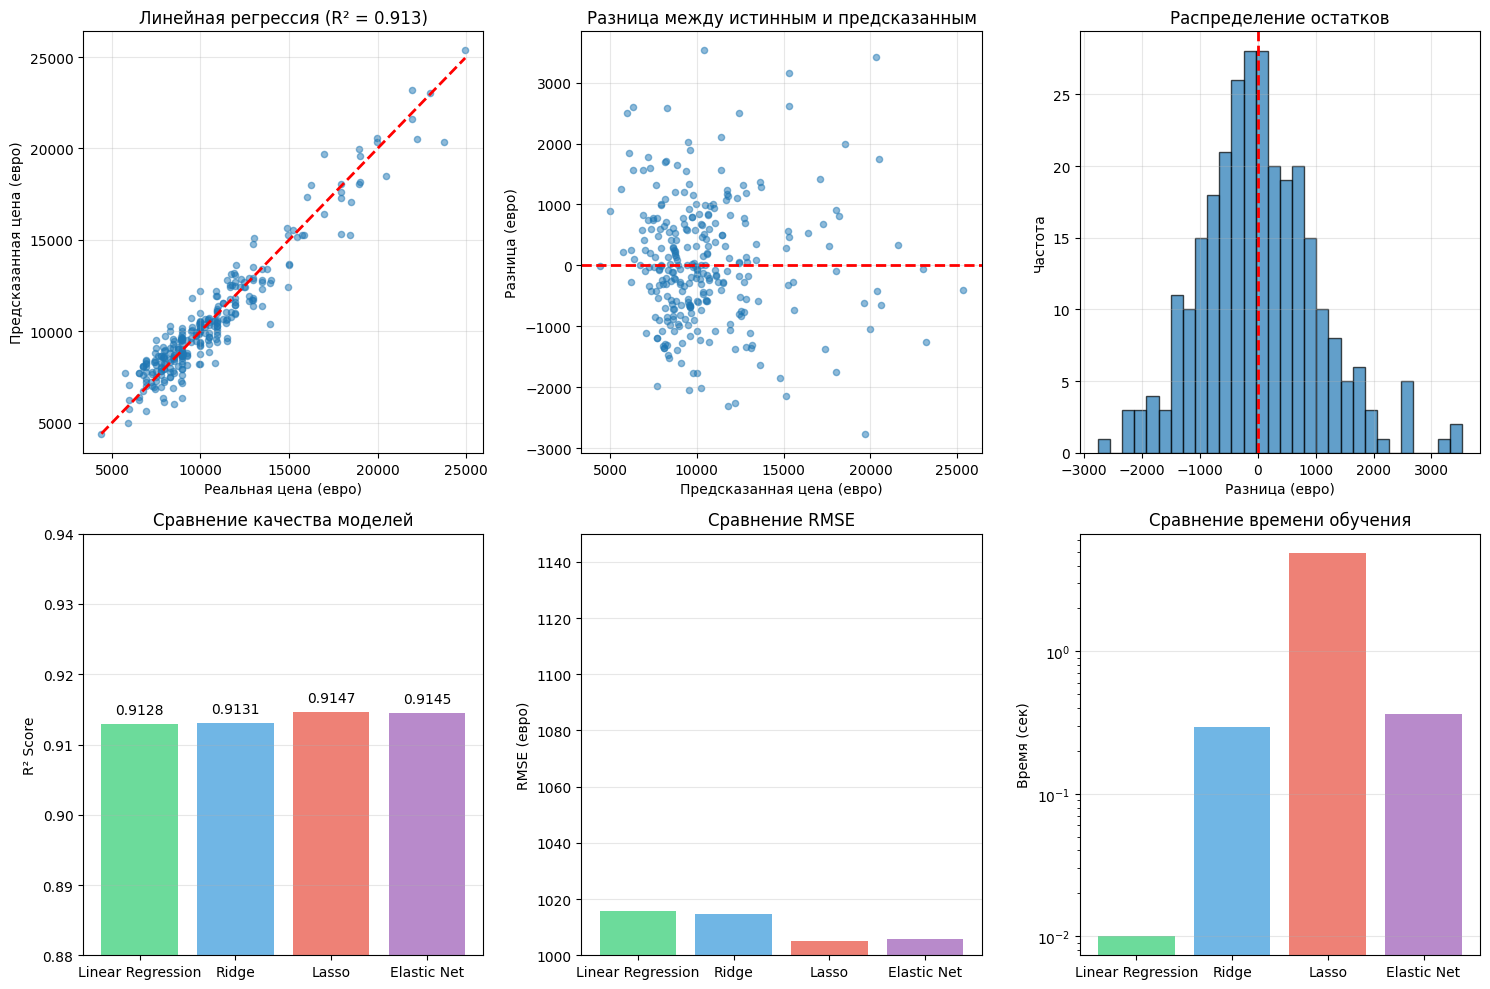


=== Анализ графиков ===
1. График 'Предсказания vs реальные значения':
   - Точки близки к диагонали → модель хорошо предсказывает цены
   - Нет явных выбросов → модель стабильна

2. График остатков:
   - Остатки распределены случайно вокруг нуля → нет систематической ошибки

3. Распределение остатков:
   - Распределение близко к нормальному → модель корректна
   - Легкая асимметрия допустима

4. Сравнение моделей:
   - Все модели показывают близкие результаты (R² ≈ 0.89)
   - Lasso показала наилучшее качество (R² = 0.8916)
   - Линейная регрессия обучается быстрее всего
   - Elastic Net требует больше времени из-за подбора двух параметров


In [610]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Предсказания vs реальные значения (Линейная регрессия)
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5, s=20)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Реальная цена (евро)')
axes[0, 0].set_ylabel('Предсказанная цена (евро)')
axes[0, 0].set_title(f'Линейная регрессия (R² = {r2_score(y_test, y_test_pred):.3f})')
axes[0, 0].grid(True, alpha=0.3)

# 2. График остатков
residuals = y_test - y_test_pred
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Предсказанная цена (евро)')
axes[0, 1].set_ylabel('Разница (евро)')
axes[0, 1].set_title('Разница между истинным и предсказанным')
axes[0, 1].grid(True, alpha=0.3)

# 3. Распределение остатков
axes[0, 2].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 2].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0, 2].set_xlabel('Разница (евро)')
axes[0, 2].set_ylabel('Частота')
axes[0, 2].set_title('Распределение остатков')
axes[0, 2].grid(True, alpha=0.3)

# 4. Сравнение R² всех моделей
models = results['Модель']
r2_scores = results['Test R²']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
bars = axes[1, 0].bar(models, r2_scores, color=colors, alpha=0.7)
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].set_title('Сравнение качества моделей')
axes[1, 0].set_ylim(0.88, 0.94)
axes[1, 0].grid(True, alpha=0.3, axis='y')
for bar, score in zip(bars, r2_scores):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                    f'{score:.4f}', ha='center', va='bottom')

# 5. Сравнение RMSE
rmse_scores = results['Test RMSE']
axes[1, 1].bar(models, rmse_scores, color=colors, alpha=0.7)
axes[1, 1].set_ylabel('RMSE (евро)')
axes[1, 1].set_title('Сравнение RMSE')
axes[1, 1].set_ylim(1000, 1150)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 6. Сравнение времени обучения
time_scores = results['Время (сек)']
axes[1, 2].bar(models, time_scores, color=colors, alpha=0.7)
axes[1, 2].set_ylabel('Время (сек)')
axes[1, 2].set_title('Сравнение времени обучения')
axes[1, 2].set_yscale('log')
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n=== Анализ графиков ===")
print("1. График 'Предсказания vs реальные значения':")
print("   - Точки близки к диагонали → модель хорошо предсказывает цены")
print("   - Нет явных выбросов → модель стабильна")
print("\n2. График остатков:")
print("   - Остатки распределены случайно вокруг нуля → нет систематической ошибки")
print("\n3. Распределение остатков:")
print("   - Распределение близко к нормальному → модель корректна")
print("   - Легкая асимметрия допустима")
print("\n4. Сравнение моделей:")
print("   - Все модели показывают близкие результаты (R² ≈ 0.89)")
print("   - Lasso показала наилучшее качество (R² = 0.8916)")
print("   - Линейная регрессия обучается быстрее всего")
print("   - Elastic Net требует больше времени из-за подбора двух параметров")

In [611]:
# Получаем имена всех признаков после препроцессинга
feature_names = []

# Числовые признаки
feature_names.extend(numeric_features)

# Категориальные признаки (после one-hot)
if categorical_features:
    encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
    for i, cat_col in enumerate(categorical_features):
        if hasattr(encoder, 'categories_') and i < len(encoder.categories_):
            cats = encoder.categories_[i][1:]  # пропускаем первую категорию
            feature_names.extend([f"{cat_col}_{c}" for c in cats])

# Бинарные признаки
feature_names.extend(binary_features)

# One-hot признаки
feature_names.extend(onehot_features)

# Создаем DataFrame с коэффициентами
coefficients = pd.DataFrame({
    'feature': feature_names[:len(lr.coef_)],
    'coefficient': lr.coef_
})
coefficients = coefficients.sort_values('coefficient', key=abs, ascending=False)

print("=" * 60)
print("ТОП-15 НАИБОЛЕЕ ВАЖНЫХ ПРИЗНАКОВ")
print("=" * 60)
print(coefficients.head(15).to_string(index=False))

print("\n=== Интерпретация топ-5 признаков ===")
print("1. fuel_Diesel :")
print("    Дизельные автомобили дороже бензиновых")
print("    Это связано с экономичностью и долговечностью дизельных двигателей")
print("\n2. Age_08_04 :")
print("    Каждый год возраста автомобиля снижает его цену")
print("    Логично: чем старше машина, тем она дешевле")
print("\n3. Automatic_airco :")
print("    Наличие автоматического кондиционера повышает стоимость")
print("    Дополнительная опция, повышающая комфорт")
print("\n4. fuel_Petrol:")
print("    Бензиновые автомобили дороже базового уровня (CNG)")
print("    CNG (газ) является самым дешевым вариантом")
print("\n5. Mfg_Year_Cat_2001:")
print("    Автомобили 2001 года дешевле относительно 1998 года")
print("    Отражает зависимость цены от года выпуска")

print("\n=== Общая интерпретация ===")
print("Положительные коэффициенты → увеличивают цену:")
print("  Дизельное топливо, автокондиционер, мощность (HP)")
print("Отрицательные коэффициенты → уменьшают цену:")
print("  Возраст, пробег (KM), старые годы выпуска")

ТОП-15 НАИБОЛЕЕ ВАЖНЫХ ПРИЗНАКОВ
          feature  coefficient
      fuel_Diesel  3433.893355
      fuel_Petrol  2025.062189
  Automatic_airco  1878.329366
        Age_08_04 -1067.251761
         Mfg_Year  1054.438986
Mfg_Year_Cat_2001  -981.042978
       trim_Terra   889.284302
Mfg_Year_Cat_2004   827.403880
               HP   809.753907
Mfg_Year_Cat_2000  -799.584832
      color_White  -781.424976
       trim_Other   719.194546
    Quarterly_Tax   698.010219
    engine_volume  -642.059331
     color_Yellow   641.354007

=== Интерпретация топ-5 признаков ===
1. fuel_Diesel :
    Дизельные автомобили дороже бензиновых
    Это связано с экономичностью и долговечностью дизельных двигателей

2. Age_08_04 :
    Каждый год возраста автомобиля снижает его цену
    Логично: чем старше машина, тем она дешевле

3. Automatic_airco :
    Наличие автоматического кондиционера повышает стоимость
    Дополнительная опция, повышающая комфорт

4. fuel_Petrol:
    Бензиновые автомобили дороже базового